In [13]:
import sys
sys.path.append('../')
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pickle
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations
from utils.metrics import *
import random
import time
import os

from utils.metrics import RMSE
import utils.metrics as metrics
from simulators.ricker import ricker

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import warnings
warnings.filterwarnings('ignore')

In [14]:
N = 128
NUM_SIMULATIONS = 1024
BATCH_SIZE = 256
T_RICKER = 100
SAMPLE_SIZE = 256

RICKER = "ricker"
QMC = "qmc"

In [15]:
# you can pre-generate the data using generate_data.py
x = torch.tensor(np.load(f"../data/{RICKER}_x_1024.npy")).reshape(1024, N, T_RICKER).to(device)
theta = np.load(f"../data/{RICKER}_theta_1024.npy")

x_qmc = torch.tensor(np.load(f"../data/{RICKER}_x_1024_{QMC}.npy")).reshape(1024, N, T_RICKER).to(device)
theta_qmc = np.load(f"../data/{RICKER}_theta_1024_{QMC}.npy")
u_qmc = torch.tensor(np.load(f"../data/{RICKER}_u_1024_{QMC}.npy")).to(device)

dataloader = DataLoader(x[:NUM_SIMULATIONS], batch_size=BATCH_SIZE, shuffle=True)
dataloader_qmc = DataLoader(x_qmc[:NUM_SIMULATIONS], batch_size=BATCH_SIZE, shuffle=True)

In [16]:
def regression_ABC(s_obs, param, sumStats, p):
    def mad(data):
        return np.mean(np.abs(data - np.mean(data, axis=0)), axis=0)

    if param.shape[0] < param.shape[1]:
        param = np.transpose(param)

    if sumStats.shape[0] < sumStats.shape[1]:
        sumStats = np.transpose(sumStats)
    
    M = len(param)
    M_epsilon = int(M*p)
    sumStats = sumStats
    s_obs = s_obs

    norm_factor = mad(sumStats)

    norm_sumStats = sumStats / norm_factor
    norm_s_obs = s_obs / norm_factor

    distance = np.linalg.norm(norm_sumStats - norm_s_obs, axis = 1)
    max_accepted_distance = np.sort(distance)[M_epsilon - 1]

    posterior_samples = param[distance <= max_accepted_distance, :]
    norm_sumStats_star = norm_sumStats[distance <= max_accepted_distance, :]

    weights = 1 - (distance[distance <= max_accepted_distance] / max_accepted_distance)**2
    W = np.diag(weights)

    s_obs_norm = np.tile(norm_s_obs, (M_epsilon,1))
    X = np.column_stack((np.ones(shape = (M_epsilon,1)), norm_sumStats_star - s_obs_norm))

    A = np.matmul(X.T, W)

    solution = np.linalg.solve(np.matmul(A, X), np.matmul(A, posterior_samples))

    beta = solution[1:,:]

    posterior_samples_adjusted = posterior_samples - np.matmul((norm_sumStats_star - s_obs_norm), beta)

    return posterior_samples_adjusted
    

In [17]:
class RickerSummary(nn.Module):
    def __init__(self, input_size, hidden_dim):
        super(RickerSummary, self).__init__()

        self.hidden_dim = hidden_dim
        self.input_size = input_size
        
        self.encoder = nn.Sequential(nn.Conv1d(self.input_size, 4, 3, 4),
                                     nn.Conv1d(4, 4, 3, 4),
                                     nn.Conv1d(4, 4, 3, 4),
                                     )
        
        self.decoder = nn.Sequential(nn.ConvTranspose1d(4, 4, 3, 4),
                                     nn.ConvTranspose1d(4, 4, 3, 4),
                                     nn.ConvTranspose1d(4, self.input_size, 3, 4),
                                     nn.Upsample(100)
                                     )

    def forward(self, Y):
        embeddings = self.encoder(Y.reshape(-1, 1, 100))
        output = self.decoder(embeddings.reshape(-1, 4, 1)).reshape(-1, N, 100)
        return output
    
    def forward_encoder(self, Y):
        embeddings = self.encoder(Y.reshape(-1, 1, 100)).reshape(-1, N, 4)
        return embeddings

# ABC

In [18]:
def solve_normal():
    summary_net_normal = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_normal.parameters(), lr=0.01)

    # Train the model for some number of epochs
    num_epochs = 10
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader:
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_normal(inputs)
            loss = criterion(outputs, inputs) / (N*T_RICKER)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_normal

# ABC-RS

In [19]:
def solve_robust(beta, obs_cont, sample_size):
    summary_net_robust = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_robust.parameters(), lr=0.01)

    index_list = [int(i) for i in range(len(x))]

    num_epochs = 10
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader:
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_robust(inputs)

            random.shuffle(index_list)
            context_embeddings = torch.mean(summary_net_robust.forward_encoder(x[index_list[:sample_size]]), dim=1)
            obs_embeddings = torch.mean(summary_net_robust.forward_encoder(obs_cont), dim=1)

            ae_loss = criterion(outputs, inputs) / (N*T_RICKER)
            summary_loss = metrics.MMD_unweighted(context_embeddings, obs_embeddings, lengthscale=metrics.median_heuristic(context_embeddings))

            loss = ae_loss + beta*summary_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_robust

# Efficient ABC-RS

In [20]:
def solve_robust_efficient(beta, obs_cont, sample_size):
    summary_net_robust = RickerSummary(1, 4).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(summary_net_robust.parameters(), lr=0.01)

    index_list = [int(i) for i in range(len(x_qmc))]

    num_epochs = 10
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for data in dataloader_qmc:
            inputs = data
            optimizer.zero_grad()

            outputs = summary_net_robust(inputs)

            random.shuffle(index_list)
            theta = theta_qmc[index_list[:sample_size]]
            x = x_qmc[index_list[:sample_size]]
            u = u_qmc[index_list[:sample_size]]
                        
            context_embeddings = torch.mean(summary_net_robust.forward_encoder(x), dim=1)
            obs_embeddings = torch.mean(summary_net_robust.forward_encoder(obs_cont), dim=1)

            ae_loss = criterion(outputs, inputs) / (N*T_RICKER)
            
            u_flat = u.reshape(u.shape[0], -1).float()
            z = embedding_Gaussian(u_flat)
            w = computeWeights(u_flat, z)
            
            summary_loss = MMD_weighted(context_embeddings, obs_embeddings, w, lengthscale=metrics.median_heuristic(context_embeddings))

            loss = ae_loss + beta*summary_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader)}")
    return summary_net_robust

# Main training loop

In [21]:
degrees = [0, 0.1, 0.2]

for degree in degrees:
    obs_cont = torch.tensor(np.load(f"../data/ricker_obs_{int(degree * 10)}.npy")).to(device)

    n_sims = 5 # 100
    beta_list = [1, 2, 3, 4, 5, 10]
    for beta in beta_list:
        for i in range(n_sims):
            print(f"Simulation {i}")
            summary_net_normal = solve_normal()
            s_normal = torch.mean(summary_net_normal.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_normal = torch.mean(summary_net_normal.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_normal = regression_ABC(s_obs_normal, theta, s_normal, 0.05)

            summary_net_robust = solve_robust(beta, obs_cont, SAMPLE_SIZE)
            s_robust = torch.mean(summary_net_robust.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_robust = torch.mean(summary_net_robust.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_robust = regression_ABC(s_obs_robust, theta, s_robust, 0.05)

            # Lower sample size for efficient model: refer to SAMPLE_SIZE for what is currently used
            summary_net_robust_efficient = solve_robust_efficient(beta, obs_cont, SAMPLE_SIZE)
            s_robust_efficient = torch.mean(summary_net_robust_efficient.forward_encoder(x).cpu(), dim=1).detach().numpy()
            s_obs_robust_efficient = torch.mean(summary_net_robust_efficient.forward_encoder(obs_cont).cpu(), dim=1).detach().numpy()
            posterior_robust_efficient = regression_ABC(s_obs_robust_efficient, theta, s_robust_efficient, 0.05)

            root_name = f'../objects/ABC/ricker_final/degree={degree}/lambda={beta}/' + str(i)
            if not os.path.exists(root_name):
                os.makedirs(root_name)
            np.save(root_name + '/posterior_normal.npy', posterior_normal)
            np.save(root_name + '/posterior_robust.npy', posterior_robust)
            np.save(root_name + '/posterior_robust_efficient.npy', posterior_robust_efficient)

Simulation 0
Epoch 1, Loss: 12.669447422027588
Epoch 2, Loss: 12.622633576393127
Epoch 3, Loss: 12.491044282913208
Epoch 4, Loss: 12.015953779220581
Epoch 5, Loss: 10.848487138748169
Epoch 6, Loss: 9.364235639572144
Epoch 7, Loss: 9.24809193611145
Epoch 8, Loss: 8.7407386302948
Epoch 9, Loss: 8.847193598747253
Epoch 10, Loss: 8.714992761611938
Epoch 1, Loss: 12.676962852478027
Epoch 2, Loss: 12.071469783782959
Epoch 3, Loss: 10.853749752044678
Epoch 4, Loss: 9.251994848251343
Epoch 5, Loss: 9.301981687545776
Epoch 6, Loss: 8.93228805065155
Epoch 7, Loss: 8.987366557121277
Epoch 8, Loss: 8.97559905052185
Epoch 9, Loss: 8.846422910690308
Epoch 10, Loss: 8.887369394302368
Epoch 1, Loss: 10.568969964981079
Epoch 2, Loss: 10.462467193603516
Epoch 3, Loss: 10.170828342437744
Epoch 4, Loss: 9.457895994186401
Epoch 5, Loss: 8.247156739234924
Epoch 6, Loss: 7.499472618103027
Epoch 7, Loss: 7.720685720443726
Epoch 8, Loss: 7.372322916984558
Epoch 9, Loss: 7.535075068473816
Epoch 10, Loss: 7.4313

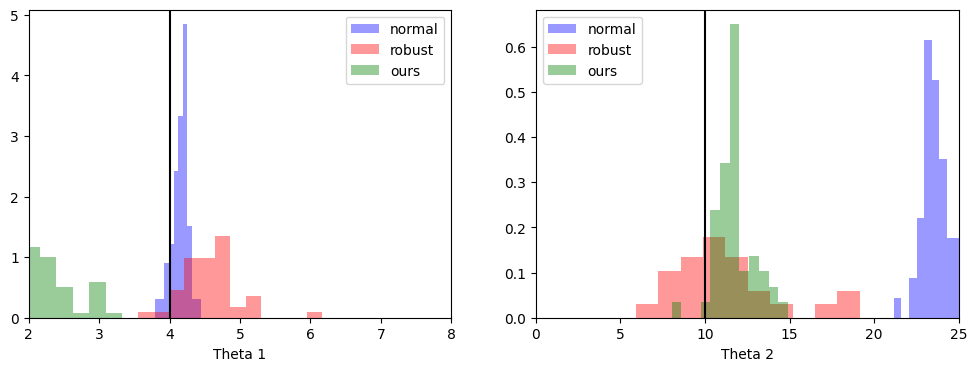

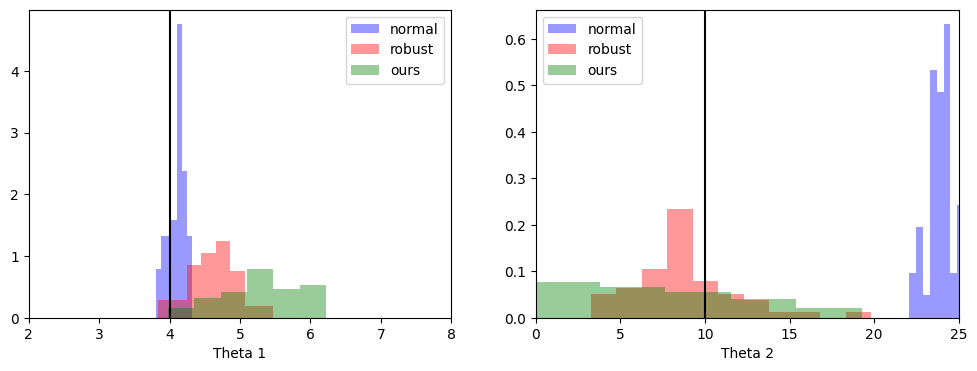

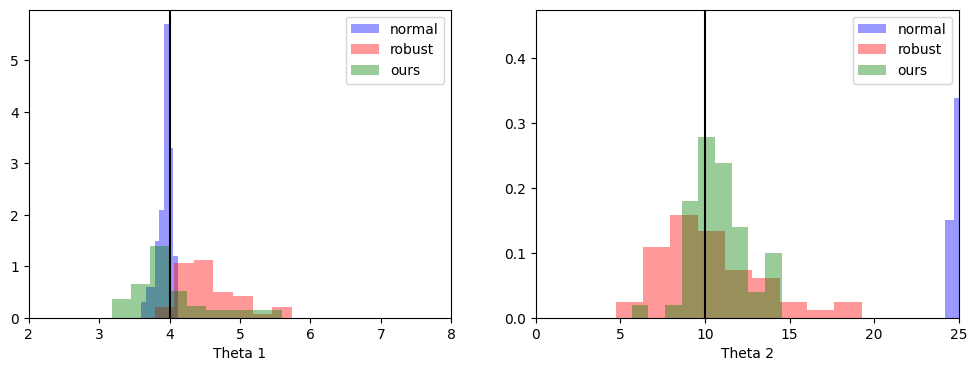

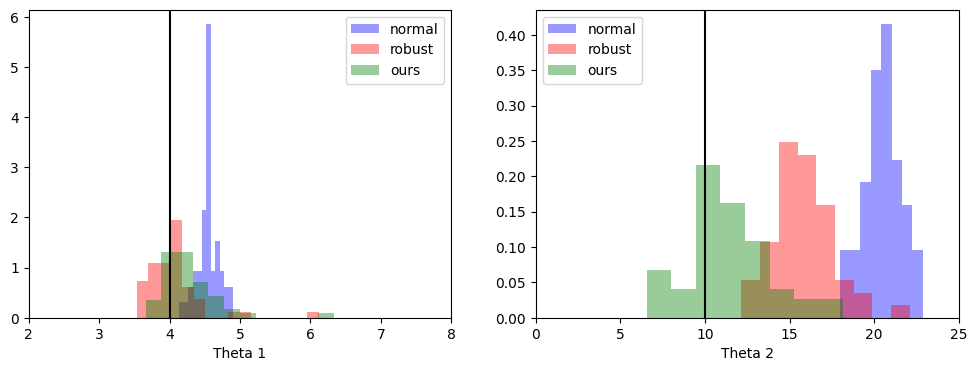

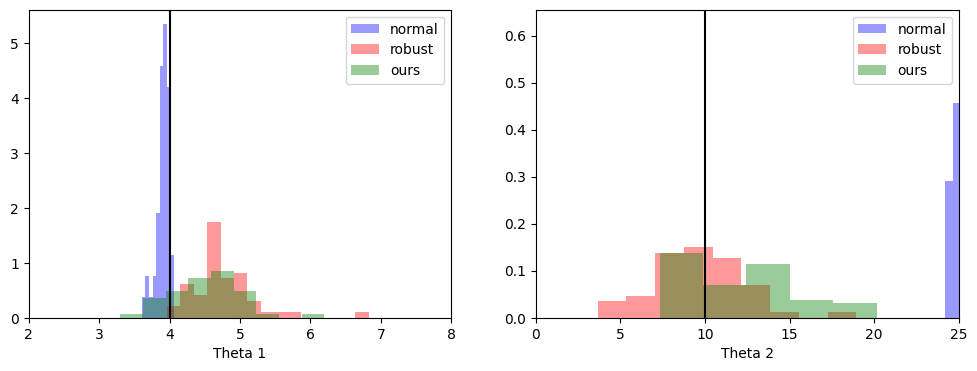

In [69]:
target_degree = 0.2
target_beta = 2
sample = 4
ss = 64

for ss in [32, 64, 128, 256, 512]:

    posterior_normal = np.load(f"../objects/ABC/ricker_consolidated/degree={target_degree}/lambda={target_beta}/sample_size={ss}/{sample}/posterior_normal.npy")
    posterior_robust = np.load(f"../objects/ABC/ricker_consolidated/degree={target_degree}/lambda={target_beta}/sample_size={ss}/{sample}/posterior_robust.npy")
    posterior_robust_efficient = np.load(f"../objects/ABC/ricker_consolidated/degree={target_degree}/lambda={target_beta}/sample_size={ss}/{sample}/posterior_efficient.npy")

    theta_gt = [4 ,10]
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.axvline(x=theta_gt[0],ls="-",c="black")
    sns.distplot(posterior_normal[:, 0], color='blue', kde=False, norm_hist=True, label="normal")
    sns.distplot(posterior_robust[:, 0], color='red', kde=False, norm_hist=True, label="robust")
    sns.distplot(posterior_robust_efficient[:, 0], color='green', kde=False, norm_hist=True, label="ours")
    plt.legend()
    plt.xlim(2, 8)
    plt.xlabel("Theta 1")

    plt.subplot(1, 2, 2)
    plt.axvline(x=theta_gt[1],ls="-",c="black")
    sns.distplot(posterior_normal[:, 1], color='blue', kde=False, norm_hist=True, label="normal")
    sns.distplot(posterior_robust[:, 1], color='red', kde=False, norm_hist=True, label="robust")
    sns.distplot(posterior_robust_efficient[:, 1], color='green', kde=False, norm_hist=True, label="ours")
    plt.legend()
    plt.xlim(0, 25)
    plt.xlabel("Theta 2")

    plt.show()

In [66]:
rmse_abc = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_normal), 2)
rmse_abc_rs = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_robust), 2)
rmse_abc_rs_e = RMSE(torch.tensor([4, 10]), torch.tensor(posterior_robust_efficient), 2)

print(f"RMSE for ABC: {rmse_abc}")
print(f"RMSE for ABC-RS: {rmse_abc_rs}")
print(f"RMSE for Efficient ABC-RS: {rmse_abc_rs_e}")

RMSE for ABC: 9.634718783559926
RMSE for ABC-RS: 2.4308164949659736
RMSE for Efficient ABC-RS: 1.9431686841101499


In [43]:
n_sims = 50
beta = 5
rmse_normal = np.zeros(n_sims)
rmse_robust = np.zeros(n_sims)
rmse_robust_efficient = np.zeros(n_sims)
for i in range(n_sims):
    root_name = f'../objects/ABC/ricker/lambda={beta}/' + str(i)
    posterior_normal = torch.tensor(np.load(root_name + '/posterior_normal.npy'))
    posterior_robust = torch.tensor(np.load(root_name + '/posterior_robust.npy'))
    posterior_robust_efficient = torch.tensor(np.load(root_name + '/posterior_robust_efficient.npy'))
    rmse_normal[i] = RMSE(torch.tensor([4, 10]), posterior_normal, 2)
    rmse_robust[i] = RMSE(torch.tensor([4, 10]), posterior_robust, 2)
    rmse_robust_efficient[i] = RMSE(torch.tensor([4, 10]), posterior_robust_efficient, 2)

print("RMSE mean for normal model: ", np.mean(rmse_normal))
print("RMSE mean for robust model: ", np.mean(rmse_robust))
print("RMSE mean for efficient robust model: ", np.mean(rmse_robust_efficient))
print("RMSE std for normal model: ", np.std(rmse_normal))
print("RMSE std for robust model: ", np.std(rmse_robust))
print("RMSE std for efficient robust model: ", np.std(rmse_robust_efficient))

FileNotFoundError: [Errno 2] No such file or directory: '../objects/ABC/ricker/lambda=2/0/posterior_normal.npy'